In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/My Drive/Crime Analysis')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
region_df = pd.read_csv('data/region/region_2024_7.csv')
region_df.head()

,市区町丁,総合計,凶悪犯計,凶悪犯強盗,凶悪犯その他,粗暴犯計,粗暴犯凶器準備集合,粗暴犯暴行,粗暴犯傷害,粗暴犯脅迫,...,非侵入窃盗万引き,非侵入窃盗その他,その他計,その他詐欺,その他占有離脱物横領,その他その他知能犯,その他賭博,その他その他刑法犯,latitude,longitude
0,千代田区丸の内１丁目,234,1,1,0,28,0,21,5,1,...,46,42,89,25,18,0,0,46,35.681560,139.767201
1,千代田区丸の内２丁目,21,0,0,0,2,0,1,1,0,...,6,4,8,3,1,0,0,4,35.680022,139.763447
2,千代田区丸の内３丁目,22,0,0,0,1,0,0,1,0,...,1,3,16,12,1,1,0,2,35.676724,139.763388
3,千代田区大手町１丁目,27,0,0,0,2,0,2,0,0,...,5,2,17,8,2,1,0,6,35.688069,139.763929
4,千代田区大手町２丁目,14,0,0,0,3,0,2,1,0,...,0,1,7,1,2,1,0,3,35.686301,139.768087


In [ ]:
def convert_kanji_to_num(s):
    if pd.isna(s):
        return s
    return s.replace('〇', '０').replace('一', '１').replace('二', '２').replace('三', '３').replace('四', '４').replace('五', '５').replace('六', '６').replace('七', '７').replace('八', '８').replace('九', '９')

In [ ]:
import geopandas as gpd
# Source: https://www.e-stat.go.jp/gis/statmap-search?page=1&type=2&aggregateUnitForBoundary=A&toukeiCode=00200521&toukeiYear=2020&serveyId=A002005212020&prefCode=13&coordsys=2&format=shape&datum=2000

subregions = gpd.read_file('data/subregions.geojson')
subregions = subregions.to_crs(epsg=4326)
subregions['市区町丁'] = subregions.apply(lambda row: f"{row['CITY_NAME']}{convert_kanji_to_num(row['S_NAME'])}", axis=1)
# subregions['市区町丁'] = subregions['CITY_NAME'] + subregions['S_NAME'].apply(convert_kanji_to_num)
subregions[subregions['CITY_NAME'].str.contains('江戸川区', na=False)].head()

,KEY_CODE,PREF,CITY,S_AREA,PREF_NAME,CITY_NAME,S_NAME,KIGO_E,HCODE,AREA,...,N_CITY,KIGO_I,KBSUM,JINKO,SETAI,X_CODE,Y_CODE,KCODE1,geometry,市区町丁
2997,13123001101,13,123,001101,東京都,江戸川区,小松川一丁目,None,8101,894247.874,...,None,None,51,5245,2417,139.850757,35.688393,0011-01,"POLYGON ((139.85377 35.69462, 139.85664 35.694...",江戸川区小松川１丁目
2998,13123001102,13,123,001102,東京都,江戸川区,小松川二丁目,None,8101,300089.755,...,None,None,44,4539,1974,139.852951,35.696191,0011-02,"POLYGON ((139.85688 35.69859, 139.85690 35.698...",江戸川区小松川２丁目
2999,13123001103,13,123,001103,東京都,江戸川区,小松川三丁目,None,8101,255864.601,...,None,None,39,4331,1616,139.851162,35.698504,0011-03,"POLYGON ((139.85683 35.69924, 139.85687 35.698...",江戸川区小松川３丁目
3000,13123001203,13,123,001203,東京都,江戸川区,小松川三丁目,None,8101,12562.238,...,None,None,3,268,121,139.849389,35.699564,0012-03,"POLYGON ((139.84819 35.69888, 139.84814 35.698...",江戸川区小松川３丁目
3001,13123001204,13,123,001204,東京都,江戸川区,小松川四丁目,None,8101,140437.209,...,None,None,15,1374,644,139.853426,35.701462,0012-04,"POLYGON ((139.85141 35.69979, 139.85043 35.699...",江戸川区小松川４丁目


In [ ]:
import networkx as nx

G = nx.Graph()

for idx, row in subregions.iterrows():
    G.add_node(idx, **row.to_dict())

for i, row_i in subregions.iterrows():
    for j, row_j in subregions.iterrows():
        if i >= j:
            continue
        if row_i['geometry'].touches(row_j['geometry']):
            G.add_edge(i, j)

In [ ]:
import pickle
with open('data/subregions_graph.pkl', 'wb') as f:
    pickle.dump(G, f)

In [ ]:
import folium
from folium.plugins import HeatMap
from folium import Choropleth
from matplotlib import cm, colors, colormaps

```python
test_df = pd.merge(region_df, subregions[['市区町丁', 'geometry']], on='市区町丁', how='left').head(-10)
test_df.head()
pd.set_option('display.max_rows', 20)
test_df[~test_df['geometry'].isna()].sort_values(by='総合計', ascending=False).head(50)
```

In [ ]:
class HeatmapBase:
    def __init__(self, df, weight_col=None):
        self.df = pd.merge(df, subregions[['市区町丁', 'geometry']], on='市区町丁', how='left')
        self.df = self.df[~self.df['geometry'].isna()]
        self.weight_col = weight_col

        combined_geometry = gpd.GeoSeries(self.df['geometry']).unary_union
        self.centroid = combined_geometry.centroid
        self.m = folium.Map(location=[self.centroid.y, self.centroid.x], zoom_start=12, tiles='cartodbpositron')
        # self.m = folium.Map(location=[35.682839, 139.759455], zoom_start=12, tiles='cartodbpositron')

    def render(self):
        if self.weight_col is not None:
            norm = colors.Normalize(vmin=self.df[self.weight_col].min(), vmax=self.df[self.weight_col].max())
            cmap = colormaps.get_cmap('viridis')

        for _, row in self.df.iterrows():
            if row['geometry'] is not None:
                if self.weight_col is not None:
                    color = colors.to_hex(cmap(norm(row[self.weight_col])))
                else:
                    color = '#3186cc'  # Default color when weight_col is None

                folium.GeoJson(
                    row['geometry'].__geo_interface__,
                    style_function=lambda _, color=color: {
                        'fillColor': color,
                        'color': None,
                        'weight': 0,
                        'fillOpacity': 0.7
                    }
                ).add_to(self.m)

        return self.m

    def reset_map(self):
        self.m = folium.Map(location=[self.centroid.y, self.centroid.x], zoom_start=12, tiles='cartodbpositron')

In [ ]:
HeatmapBase(region_df, weight_col='非侵入窃盗計').render()

NameError: name 'region_df' is not defined

In [ ]:
df = pd.DataFrame()

In [ ]:
for filename in os.listdir('data/case'):
    if filename.endswith('.csv'):
        df = pd.concat([df, pd.read_csv('data/case/' + filename)])

In [ ]:
df['発生年月日（始期）'] = pd.to_datetime(df['発生年月日（始期）'], errors='coerce')

In [ ]:
region2022 = pd.read_csv('data/region/region_2022.csv')
df['市区町丁'] = df.apply(lambda x: str(x['市区町村（発生地）']) + str(x['町丁目（発生地）']), axis=1)
reported_case_counts = df.groupby('市区町丁').size()

In [ ]:
common_regions = list(set(region2022['市区町丁']).intersection(set(df['市区町丁'])))

In [ ]:
ts_df = df.groupby(['市区町丁', df['発生年月日（始期）'].dt.date]).size().unstack(fill_value=0)
ts_2022 = ts_df[[col for col in ts_df.columns if col.year == 2022]].reindex(common_regions).dropna(how='all')

In [ ]:
region2022.loc[region2022['市区町丁'].str.contains('豊島区南池袋'), ['市区町丁', '非侵入窃盗計']]

,市区町丁,非侵入窃盗計
1948,豊島区南池袋１丁目,321
1949,豊島区南池袋２丁目,41
1950,豊島区南池袋３丁目,9
1951,豊島区南池袋４丁目,4


In [ ]:
ts_2022 = ts_2022.T
start_date = ts_2022.index.min()
end_date = ts_2022.index.max()
full_range = pd.date_range(start=start_date, end=end_date, freq='D')
ts_2022 = ts_2022.reindex(full_range)
ts_2022 = ts_2022.fillna(0)

Scale up the values using the annual crime counts reported in the regional CSV file.

<Axes: >

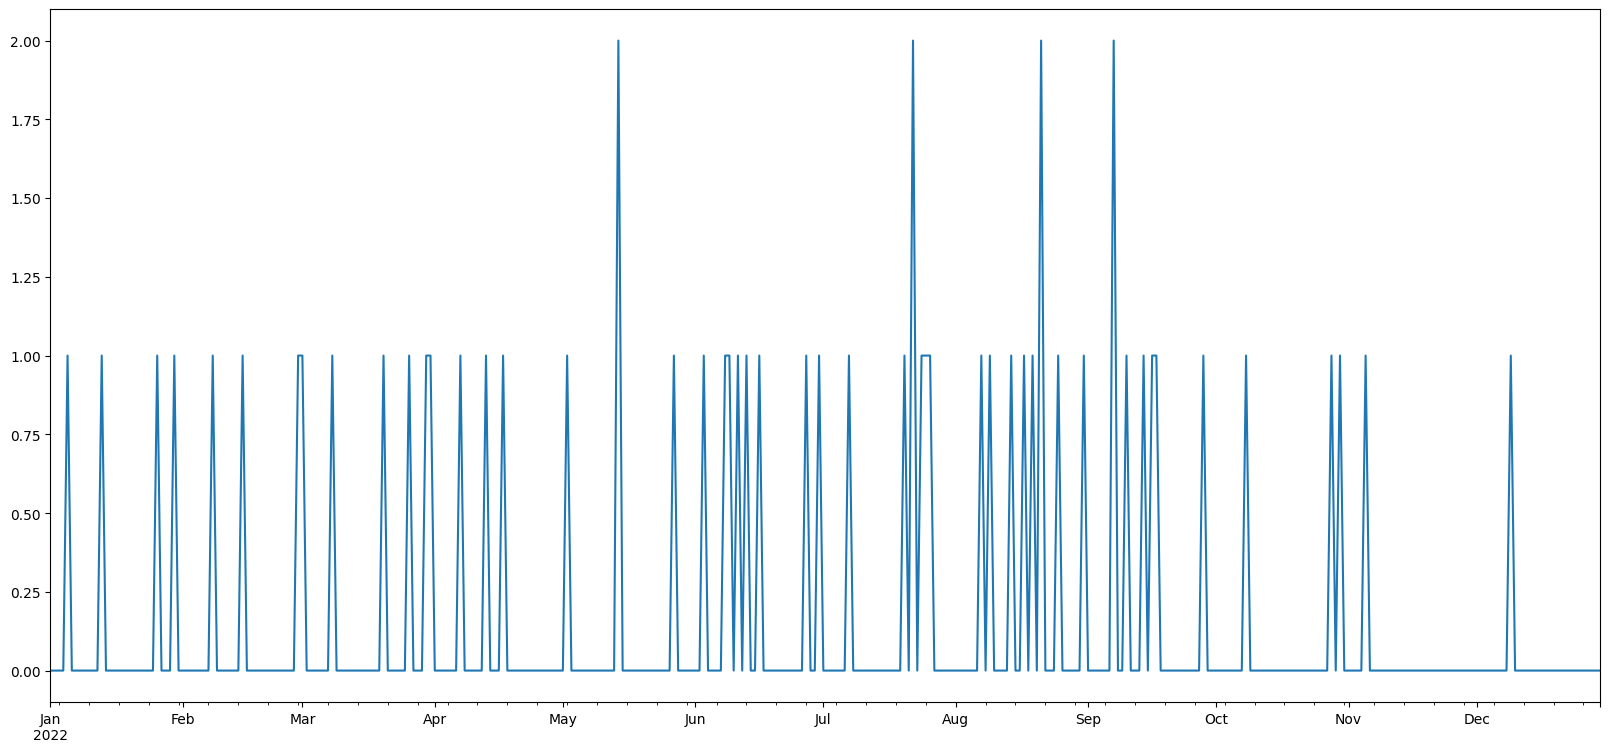

In [ ]:
shinsan_test = ts_2022['新宿区新宿３丁目']
shinsan_factor = (525 / ts_2022['新宿区新宿３丁目'].sum())
shinsan_test.plot(figsize=(20, 9))

<Axes: >

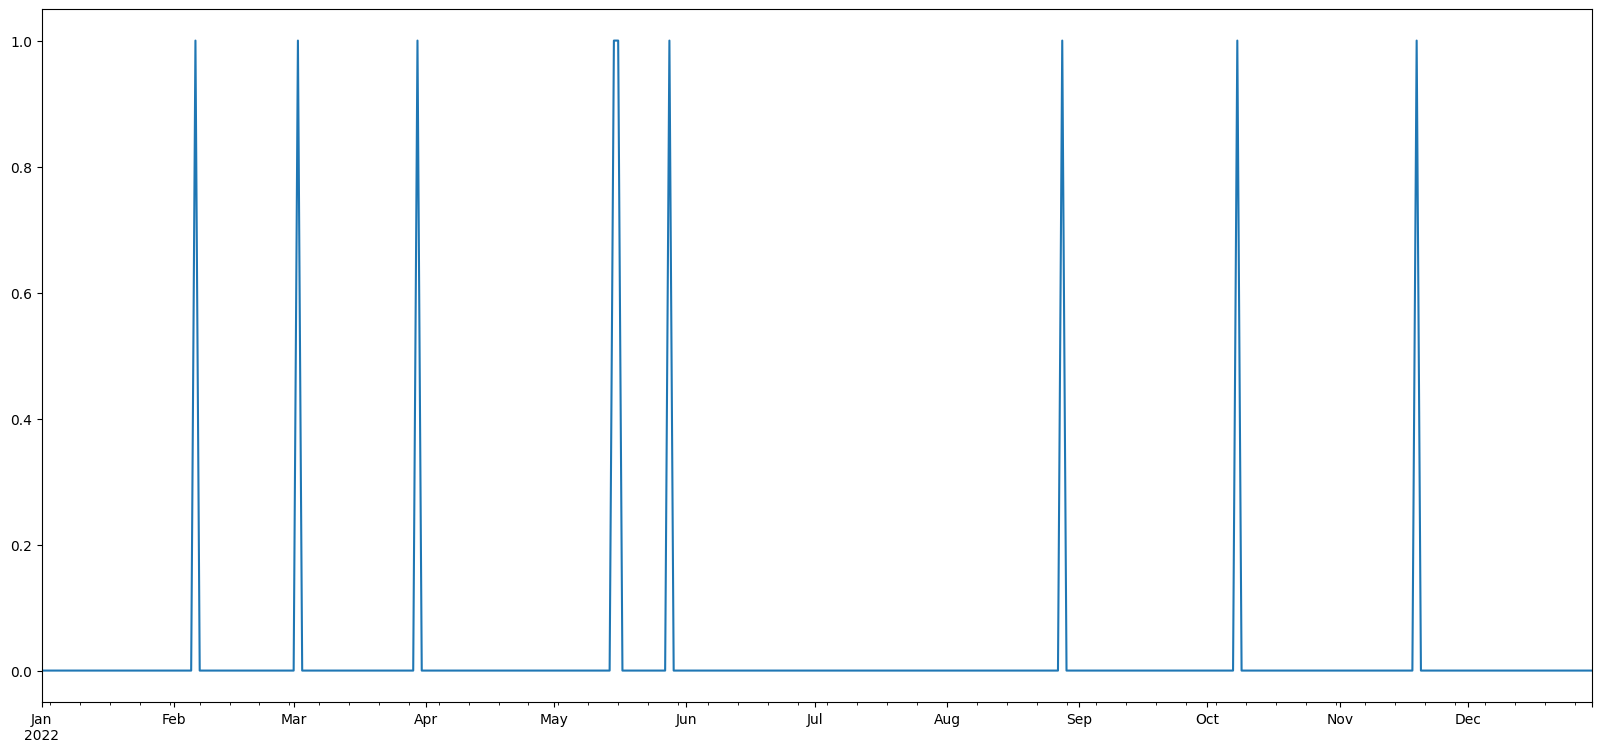

In [ ]:
ike_test = ts_2022['豊島区南池袋１丁目']
ike_factor = (321 / ts_2022['豊島区南池袋１丁目'].sum())
ike_test.plot(figsize=(20, 9))

In [ ]:
from scipy.stats import gaussian_kde
import numpy as np

data = shinsan_test.values
kde = gaussian_kde(data, bw_method=0.2)
x = np.linspace(min(data), max(data), 1000)
kde_pdf = kde.evaluate(x)

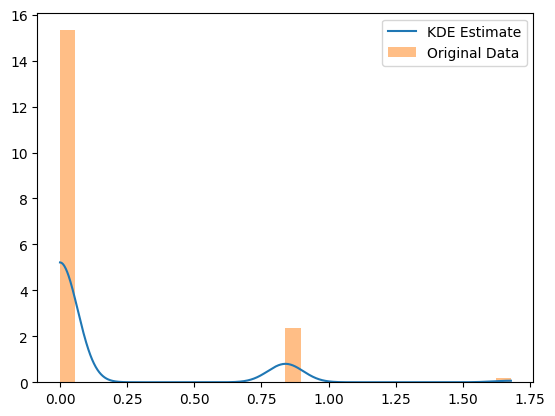

In [ ]:
# Wrong kind of density estimation, but you can use the same method for times of day
import matplotlib.pyplot as plt

plt.plot(x, kde_pdf, label='KDE Estimate')
plt.hist(data, density=True, bins=30, alpha=0.5, label='Original Data')
plt.legend()
plt.show()

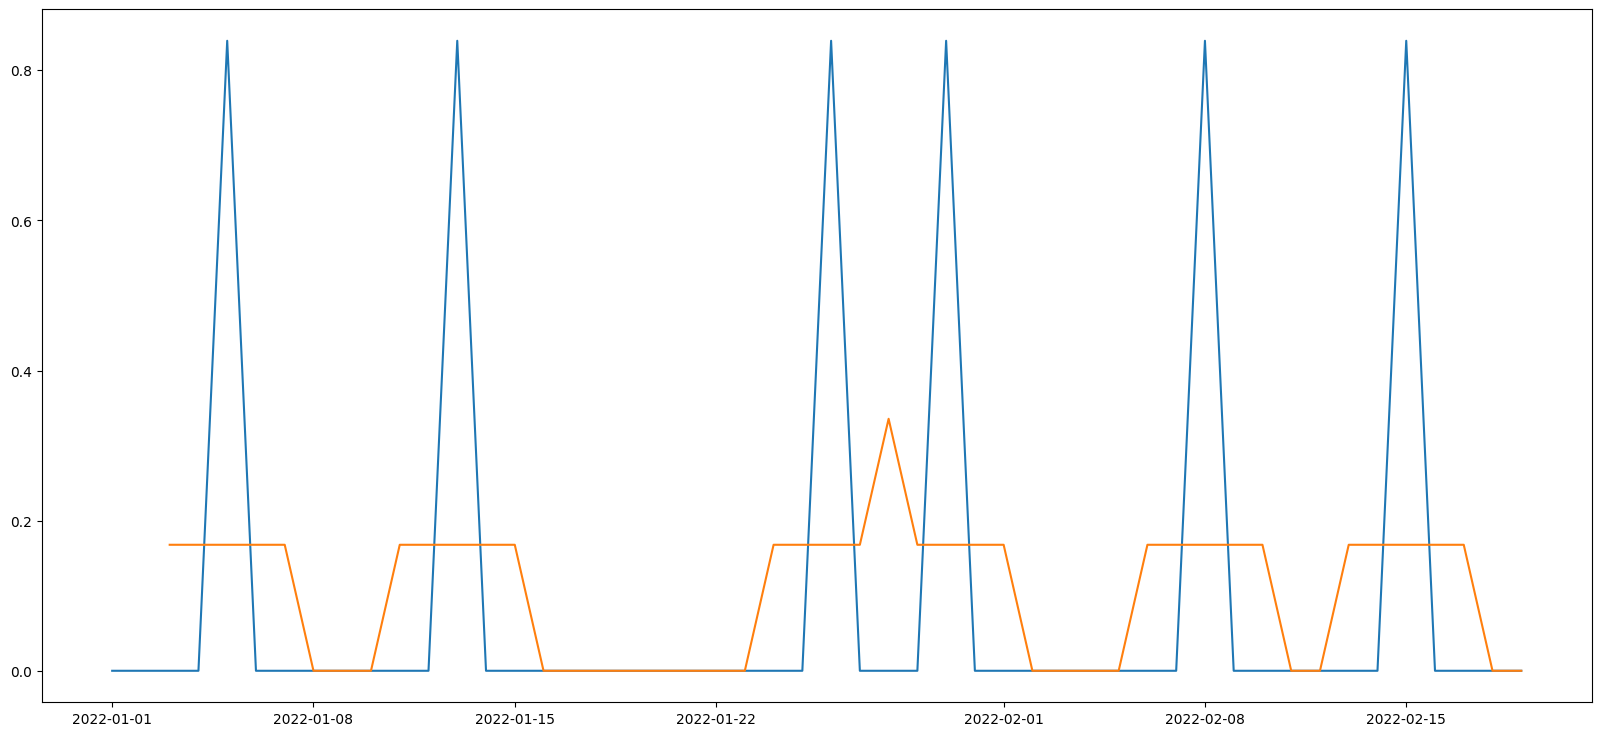

In [ ]:
plt.figure(figsize=(20, 9))
plt.plot(shinsan_test[:50])
plt.plot(shinsan_test.rolling(window=5, center=True).mean()[:50])
plt.show()

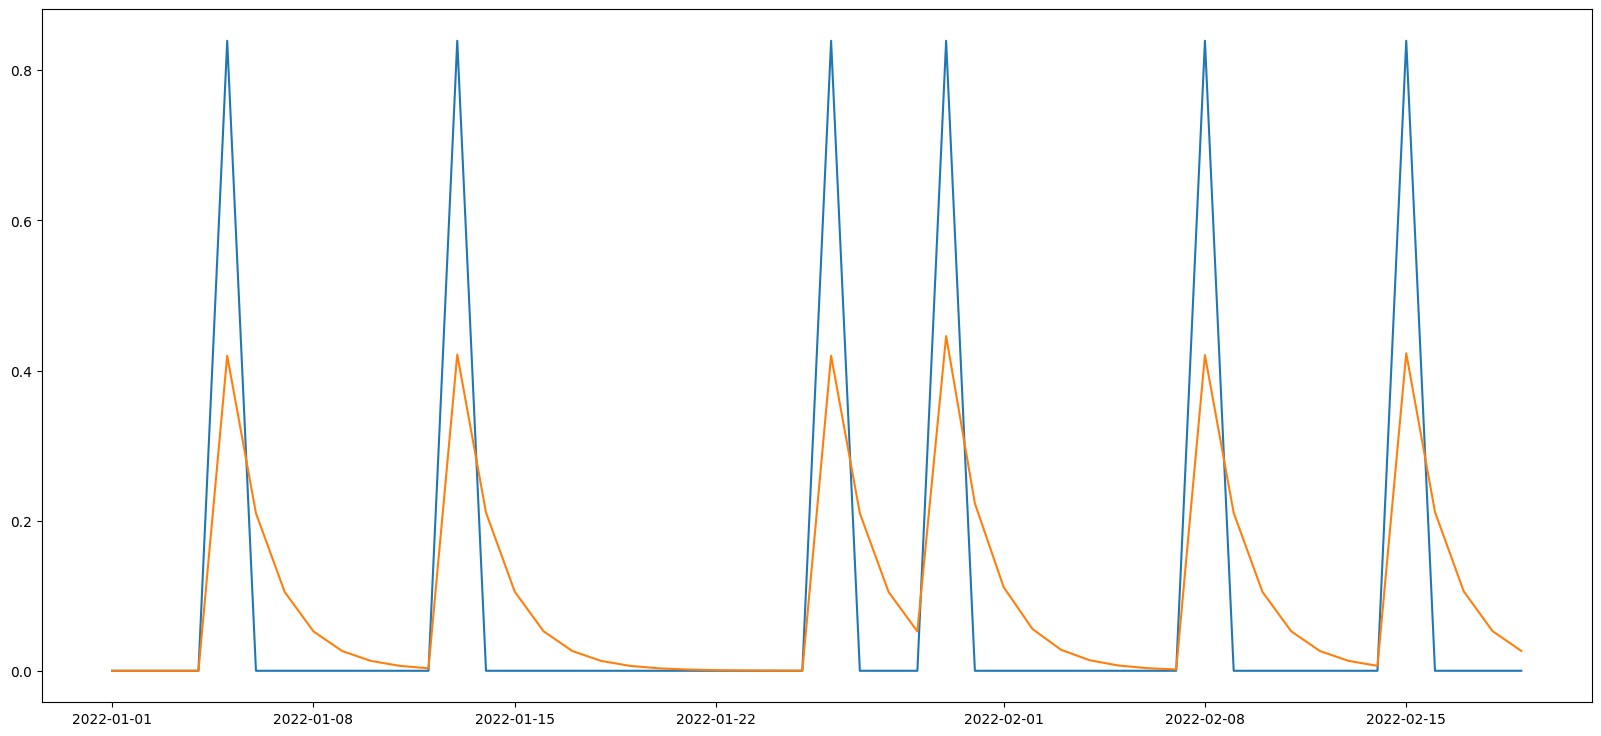

In [ ]:
plt.figure(figsize=(20, 9))
plt.plot(shinsan_test[:50])
plt.plot(shinsan_test.ewm(span=3, adjust=False).mean()[:50])
plt.show()

In [ ]:
from scipy.signal import savgol_filter, butter, filtfilt, convolve, find_peaks
from scipy.signal.windows import gaussian

# Gaussian Smoothing
def gaussian_smoothing(y, window_size=5, std=2):
    kernel = gaussian(window_size, std=std)
    kernel /= np.sum(kernel)
    return convolve(y, kernel, mode='same')

# Savitzky-Golay Filter
sg_filter = lambda y: savgol_filter(y, window_length=5, polyorder=3)

# Low-pass filter
b, a = butter(3, 0.1)
low_pass = lambda y: filtfilt(b, a, y)

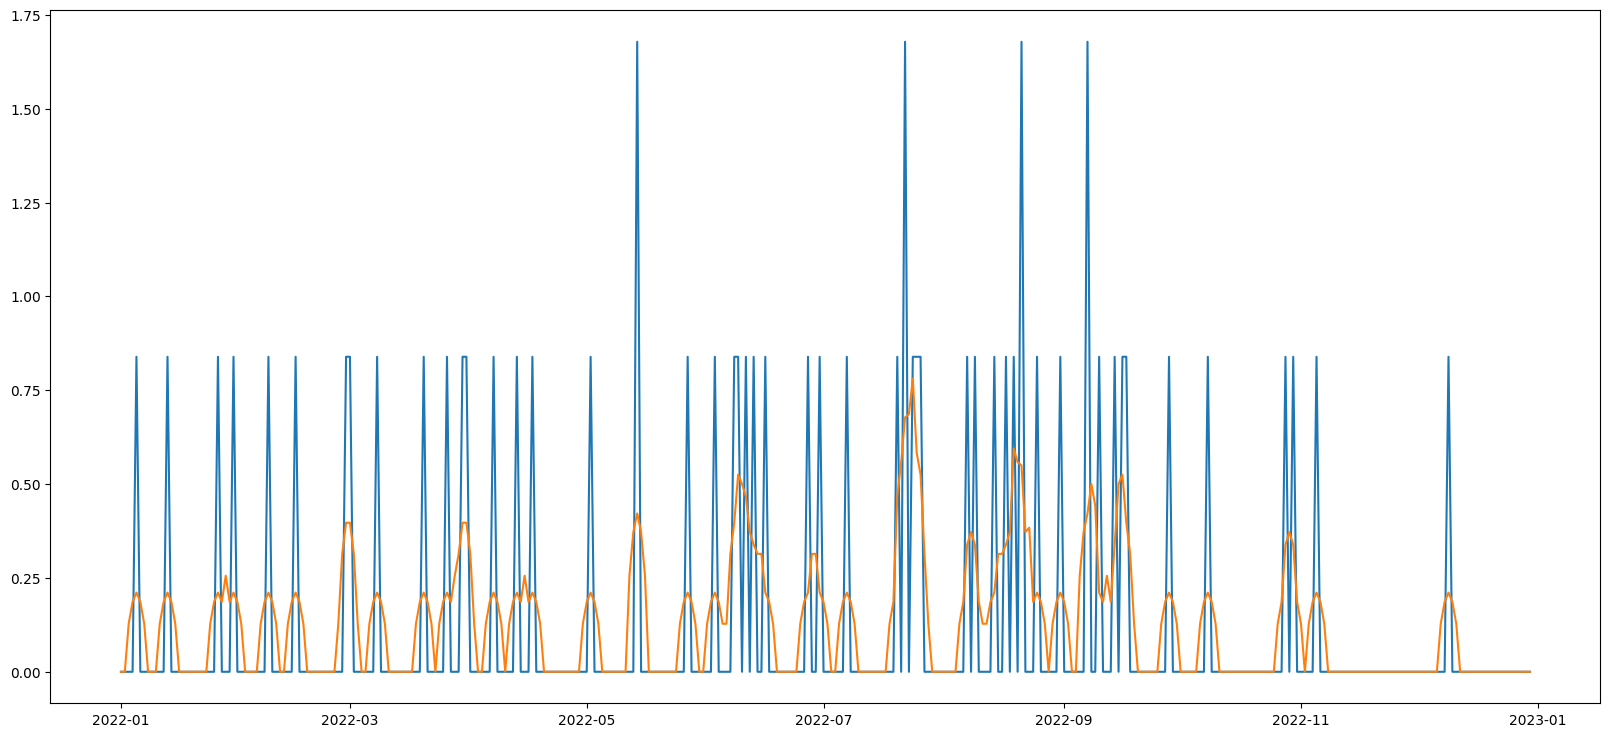

In [ ]:
plt.figure(figsize=(20, 9))
plt.plot(shinsan_test.index, shinsan_test)
plt.plot(shinsan_test.index, gaussian_smoothing(shinsan_test))
plt.show()

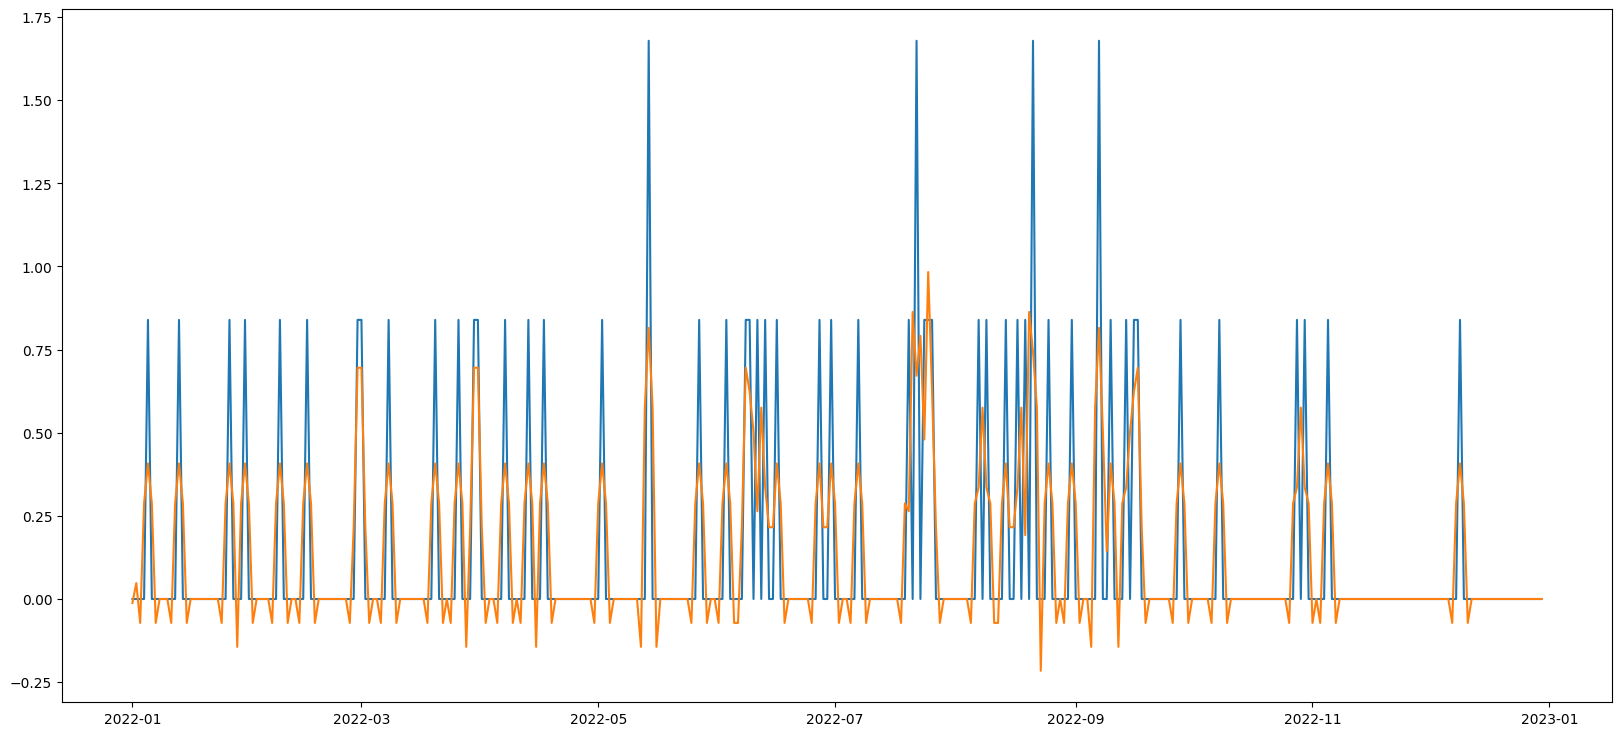

In [ ]:
plt.figure(figsize=(20, 9))
plt.plot(shinsan_test.index, shinsan_test)
plt.plot(shinsan_test.index, sg_filter(shinsan_test))
plt.show()

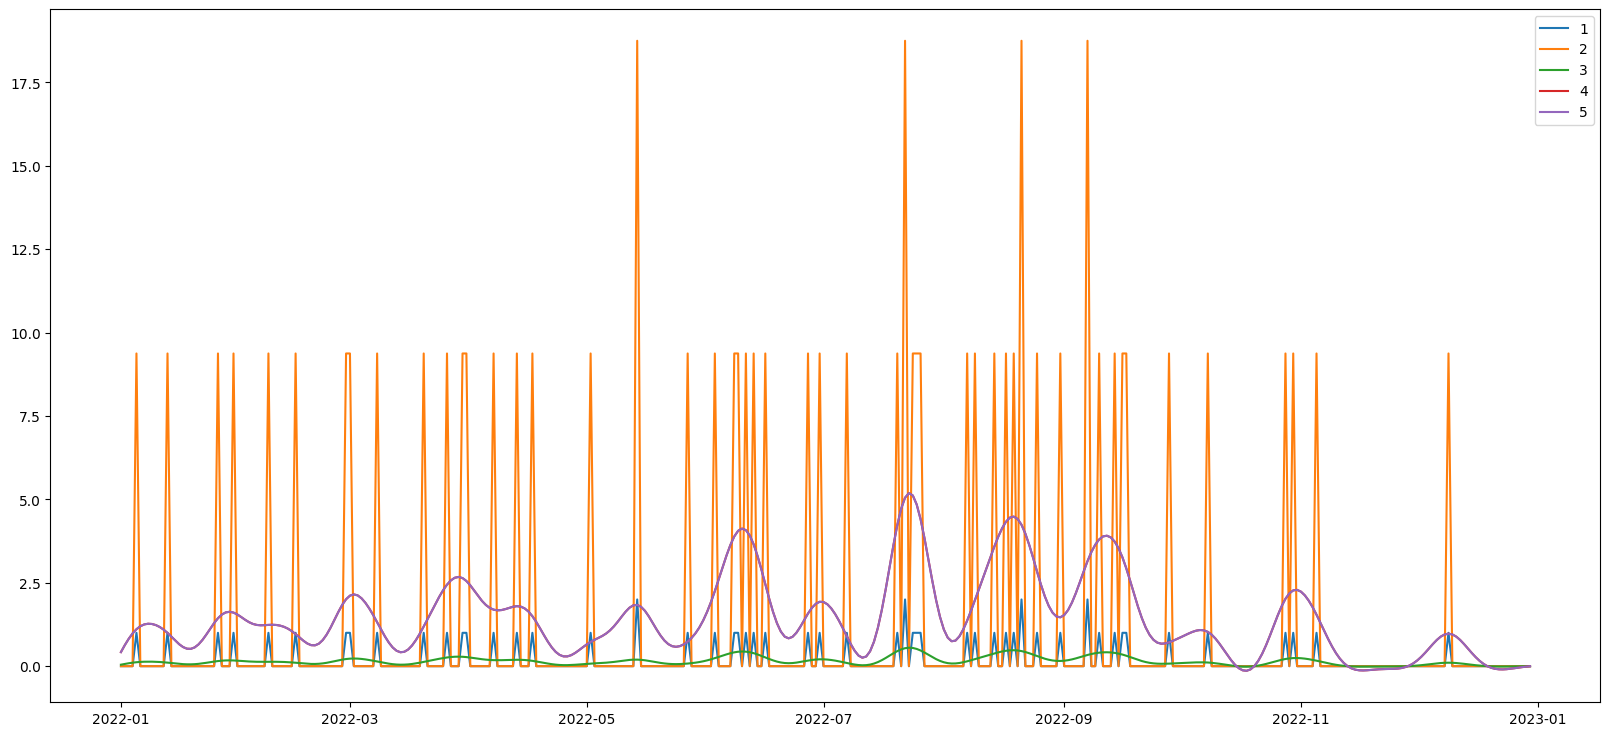

In [ ]:
plt.figure(figsize=(20, 9))
plt.plot(shinsan_test.index, shinsan_test, label='1')
plt.plot(shinsan_test.index, shinsan_test * shinsan_factor, label='2')
plt.plot(shinsan_test.index, low_pass(shinsan_test), label='3')
plt.plot(shinsan_test.index, low_pass(shinsan_test * shinsan_factor), label='4')
plt.plot(shinsan_test.index, low_pass(shinsan_test) * shinsan_factor, label='5')
plt.legend()
plt.show()

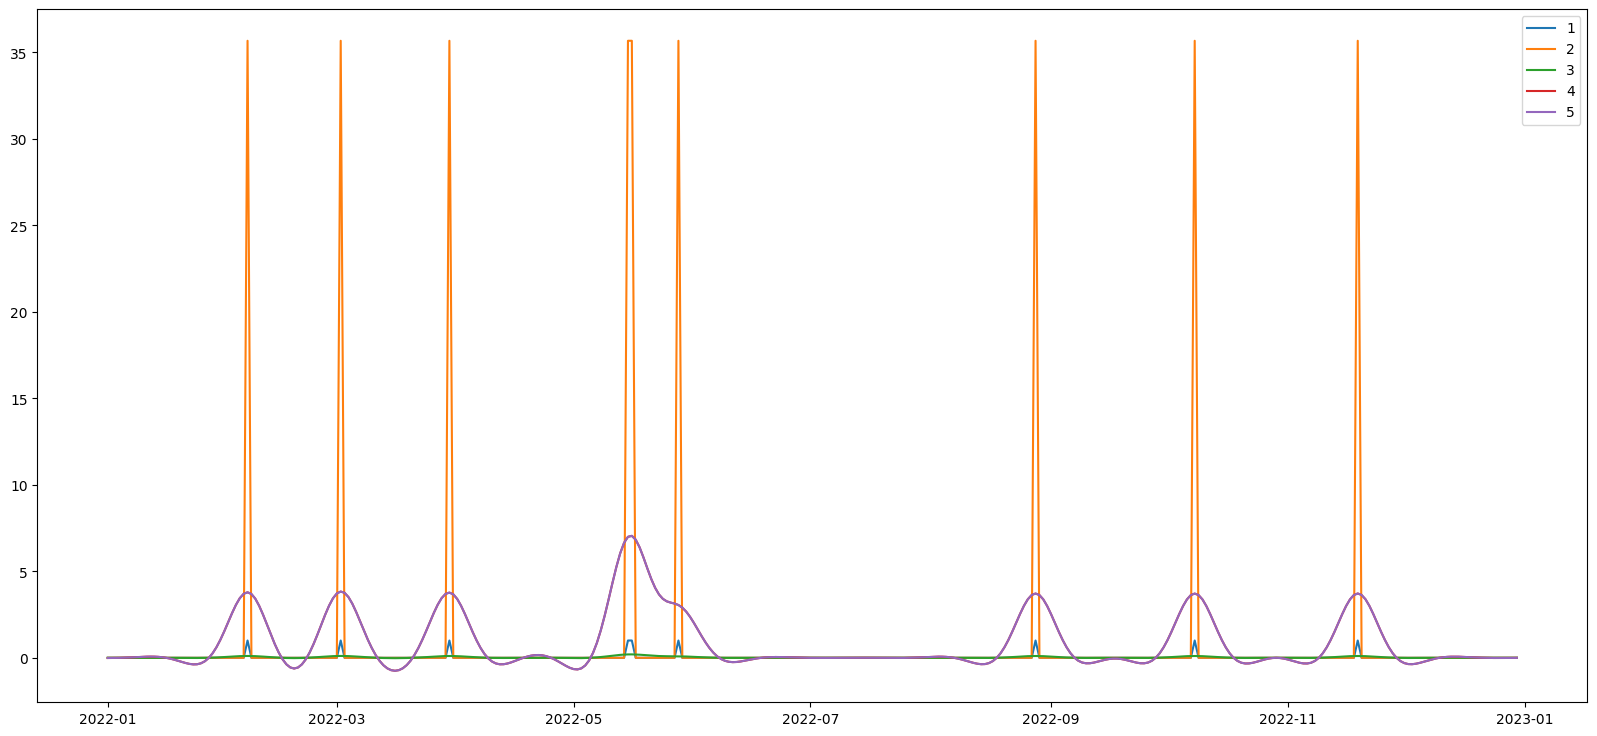

In [ ]:
plt.figure(figsize=(20, 9))
plt.plot(ike_test.index, ike_test, label='1')
plt.plot(ike_test.index, ike_test * ike_factor, label='2')
plt.plot(ike_test.index, low_pass(ike_test), label='3')
plt.plot(ike_test.index, low_pass(ike_test * ike_factor), label='4')
plt.plot(ike_test.index, low_pass(ike_test) * ike_factor, label='5')
plt.legend()
plt.show()

In [ ]:
HeatmapBase(ts_2022.T, weight_col=None).render()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
ts_2022.apply(lambda x: x.sum() == 0, axis=0).sum()

68

In [ ]:
def relu(x):
    return np.maximum(0, x)

def lpfilter_and_scale(col):
    if col.sum() > 0:
        col = low_pass(col)
        col = (col - col.min()) / (col.max() - col.min())
        col *= region2022.set_index('市区町丁').loc[col.name, '非侵入窃盗計']
        return relu(col)
    return col

ts_2022_filtered = ts_2022.apply(lpfilter_and_scale, axis=0)

In [ ]:
ts_2022_filtered

市区町丁,立川市緑町,葛飾区西新小岩１丁目,足立区扇２丁目,世田谷区代沢５丁目,府中市朝日町３丁目,三鷹市下連雀９丁目,台東区松が谷２丁目,目黒区平町１丁目,千代田区神田神保町２丁目,豊島区高松１丁目,...,東大和市向原４丁目,江戸川区興宮町,羽村市小作台４丁目,狛江市猪方２丁目,杉並区西荻北２丁目,府中市押立町１丁目,江戸川区北葛西２丁目,練馬区関町南１丁目,江戸川区篠崎町２丁目,港区芝公園３丁目
2022-01-01,0.000819,26.564665,6.979864e-04,0.000000,0.000332,2.811985e-12,7.274610e-08,2.604464e-05,0.000000e+00,7.619691e-08,...,9.621071e-17,0.000000e+00,0.000000e+00,0.000000e+00,1.688991e-15,0.000000,0.000000,0.000000e+00,0.0,4.726864e-08
2022-01-02,0.000943,22.003285,9.394751e-04,0.000000,0.279444,2.534360e-12,1.142954e-07,2.210345e-05,0.000000e+00,1.051986e-07,...,8.624702e-17,0.000000e+00,0.000000e+00,0.000000e+00,2.458871e-15,0.000000,0.000000,0.000000e+00,0.0,9.538677e-09
2022-01-03,0.001002,17.676798,1.160471e-03,0.000000,0.550876,1.861850e-12,1.577978e-07,1.416280e-05,0.000000e+00,1.326206e-07,...,6.265644e-17,0.000000e+00,0.000000e+00,0.000000e+00,3.225457e-15,0.000000,0.000000,0.000000e+00,0.0,0.000000e+00
2022-01-04,0.000966,13.790357,1.327904e-03,0.000000,0.806088,7.279903e-13,1.989308e-07,1.680277e-06,1.988767e-10,1.547108e-07,...,2.318974e-17,0.000000e+00,0.000000e+00,0.000000e+00,3.898792e-15,0.000000,0.000000,0.000000e+00,0.0,0.000000e+00
2022-01-05,0.000806,10.485079,1.402820e-03,0.000000,1.035116,0.000000e+00,2.320662e-07,0.000000e+00,1.709194e-09,1.669631e-07,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.366840e-15,0.000015,0.000000,0.000000e+00,0.0,0.000000e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-12-26,0.023309,0.000000,8.377099e-10,0.000000,0.000000,1.258341e-07,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000183,0.000000,0.000000e+00,0.0,0.000000e+00
2022-12-27,0.030298,0.000000,7.875166e-10,0.000000,0.000000,1.170416e-07,0.000000e+00,0.000000e+00,2.906957e-08,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000122,0.000340,6.415136e-10,0.0,0.000000e+00
2022-12-28,0.032923,0.000000,6.854010e-10,0.000000,0.000000,1.008921e-07,0.000000e+00,0.000000e+00,2.363767e-07,0.000000e+00,...,0.000000e+00,2.087711e-08,0.000000e+00,0.000000e+00,0.000000e+00,0.000068,0.000575,2.725205e-09,0.0,0.000000e+00
2022-12-29,0.032155,0.000000,5.539437e-10,0.009292,0.000000,8.072222e-08,8.924354e-09,2.164434e-08,3.687542e-07,0.000000e+00,...,0.000000e+00,2.108550e-07,0.000000e+00,0.000000e+00,0.000000e+00,0.000022,0.000699,4.026900e-09,0.0,0.000000e+00


<Axes: >

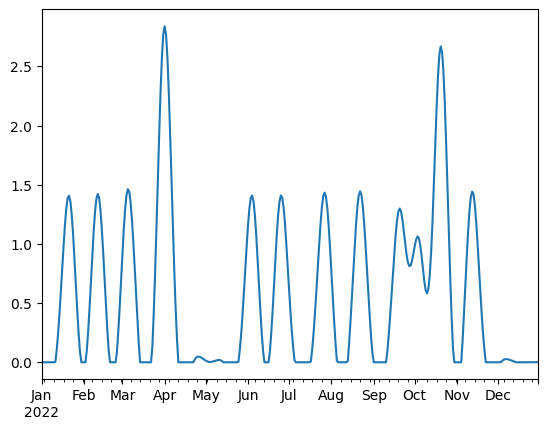

In [ ]:
ts_2022_filtered['江戸川区北葛西２丁目'].plot()

Prototype for:
- one year
- average over multiple years (to check for events that may be happening at the same time each year)
- times of day (more data that year, at least)
- apply KDE to the times of day and use that on the year timeline data

## Regression

In [ ]:
# df_dict = {} # str[pd.DataFrame]
col = '総合計'
ts_df = pd.DataFrame(columns=range(1, 8))

for df_file in os.listdir('data/region'):
    if df_file.endswith('.csv'):
        df_x = df_file.replace('region_', '').split('.')[0].split('_')
        if len(df_x) == 2:
            # ts_df[int(df_x[0])] = pd.read_csv(f'data/region/{df_file}').set_index('市区町丁').reindex(region_df['市区町丁'])[col]

            temp_df = pd.read_csv(f'data/region/{df_file}').set_index('市区町丁')
            if not temp_df.index.is_unique:
                temp_df = temp_df[~temp_df.index.duplicated(keep='first')]

            ts_df[int(df_x[1])] = temp_df[col]

In [ ]:
ts_df = ts_df[~ts_df.isna().any(axis=1)]

In [ ]:
from scipy.stats import linregress

def linreg(row):
    x = range(1, 8)
    y = row.values
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    return pd.Series({
        'slope': slope,
        'intercept': intercept
    })

In [ ]:
ts_df[['slope', 'intercept']] = ts_df.apply(linreg, axis=1)

<ipython-input-45-2c910ae8812f>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ts_df[['slope', 'intercept']] = ts_df.apply(linreg, axis=1)
<ipython-input-45-2c910ae8812f>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ts_df[['slope', 'intercept']] = ts_df.apply(linreg, axis=1)


In [ ]:
ts_df

,1,2,3,4,5,6,7,slope,intercept
市区町丁,,,,,,,,,
千代田区丸の内１丁目,36,63,102,125,166,195,234.0,32.928571,-0.142857
千代田区丸の内２丁目,3,4,6,8,15,19,21.0,3.321429,-2.428571
千代田区丸の内３丁目,5,7,10,13,16,20,22.0,2.964286,1.428571
千代田区大手町１丁目,2,5,8,11,15,21,27.0,4.071429,-3.571429
千代田区大手町２丁目,1,3,6,9,12,13,14.0,2.321429,-1.000000
...,...,...,...,...,...,...,...,...,...
多摩地区・島部計,1903,3447,5141,7140,9145,11030,13295.0,1905.214286,-320.714286
他県,12,29,65,80,94,115,139.0,20.785714,-6.857143
海外認知,0,0,3,4,4,4,6.0,0.964286,-0.857143


In [ ]:
HeatmapBase(ts_df, weight_col='slope').render()

Output hidden; open in https://colab.research.google.com to view.